In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

# Load data
DATA_PATH = '/content/drive/MyDrive/nextup data'
ratings = pd.read_csv(f'{DATA_PATH}/ratings.csv')
movies = pd.read_csv(f'{DATA_PATH}/movies.csv')

print("Ratings shape:", ratings.shape)
print("Movies shape:", movies.shape)
print("\n")
print(ratings.head())
print("\n")
print(movies.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ratings shape: (25000095, 4)
Movies shape: (62423, 3)


   userId  movieId  rating   timestamp
0       1      296     5.0  1147880044
1       1      306     3.5  1147868817
2       1      307     5.0  1147868828
3       1      665     5.0  1147878820
4       1      899     3.5  1147868510


   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                

In [9]:
print("Missing values in ratings:")
print(ratings.isnull().sum())

print("\nMissing values in movies:")
print(movies.isnull().sum())

print("\nRating distribution:")
print(ratings['rating'].describe())

Missing values in ratings:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

Missing values in movies:
movieId    0
title      0
genres     0
dtype: int64

Rating distribution:
count    2.500010e+07
mean     3.533854e+00
std      1.060744e+00
min      5.000000e-01
25%      3.000000e+00
50%      3.500000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64


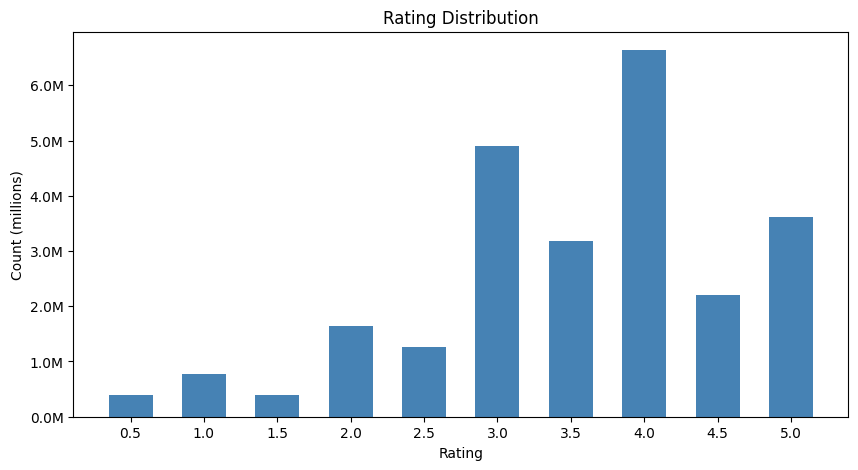

In [10]:
plt.figure(figsize=(10, 5))
rating_counts = ratings['rating'].value_counts().sort_index()
plt.bar(rating_counts.index, rating_counts.values, color='steelblue', width=0.3)
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rating_counts.index)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.ylabel('Count (millions)')
plt.show()


In [11]:
# How many movies has each user rated?
user_activity = ratings.groupby('userId')['movieId'].count()

print("User Activity Stats:")
print(user_activity.describe())

User Activity Stats:
count    162541.000000
mean        153.807932
std         268.047590
min          20.000000
25%          36.000000
50%          71.000000
75%         162.000000
max       32202.000000
Name: movieId, dtype: float64


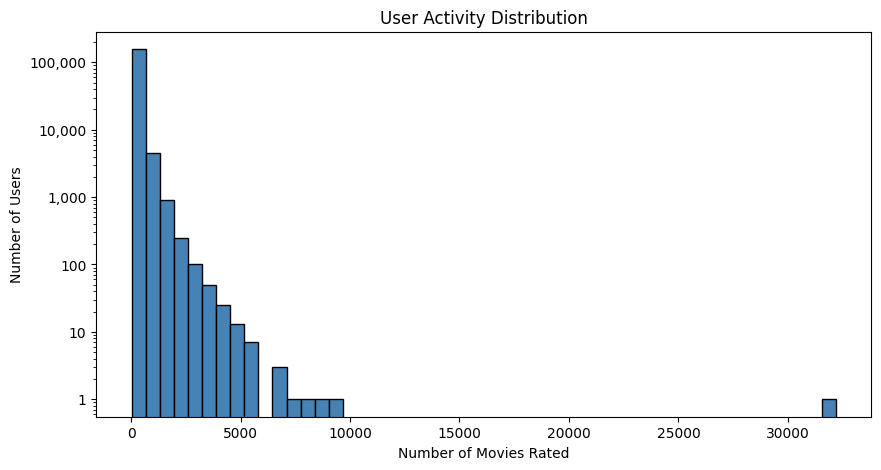

In [12]:
plt.figure(figsize=(10, 5))
plt.hist(user_activity, bins=50, color='steelblue', edgecolor='black')
plt.title('User Activity Distribution')
plt.xlabel('Number of Movies Rated')
plt.ylabel('Number of Users')
plt.yscale('log')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.show()


In [13]:
movie_activity = ratings.groupby('movieId')['userId'].count()
print("Movie Popularity Stats:")
print(movie_activity.describe())

Movie Popularity Stats:
count    59047.000000
mean       423.393144
std       2477.885821
min          1.000000
25%          2.000000
50%          6.000000
75%         36.000000
max      81491.000000
Name: userId, dtype: float64


In [14]:
# most rated movie 
most_rated = movie_activity.idxmax()
print(movies[movies['movieId'] == most_rated])

     movieId                title                    genres
351      356  Forrest Gump (1994)  Comedy|Drama|Romance|War


In [15]:
# top - 10 most rated movies 
top_movies = movie_activity.sort_values(ascending=False).head(10)
top_movie_ids = top_movies.index.tolist()
print(movies[movies['movieId'].isin(top_movie_ids)].merge(
    top_movies.reset_index().rename(columns={'userId': 'rating_count'}),
    on='movieId'
).sort_values('rating_count', ascending=False)[['title', 'rating_count']])

                                       title  rating_count
4                        Forrest Gump (1994)         81491
3           Shawshank Redemption, The (1994)         81482
2                        Pulp Fiction (1994)         79672
7           Silence of the Lambs, The (1991)         74127
8                         Matrix, The (1999)         72674
1  Star Wars: Episode IV - A New Hope (1977)         68717
5                       Jurassic Park (1993)         64144
6                    Schindler's List (1993)         60411
0                          Braveheart (1995)         59184
9                          Fight Club (1999)         58773


In [16]:
import datetime

# Convert timestamp to datetime
ratings['datetime'] = pd.to_datetime(ratings['timestamp'], unit='s')

# Extract time features
ratings['hour'] = ratings['datetime'].dt.hour
ratings['day_of_week'] = ratings['datetime'].dt.dayofweek
ratings['month'] = ratings['datetime'].dt.month
ratings['year'] = ratings['datetime'].dt.year

print(ratings[['timestamp', 'datetime', 'hour', 'day_of_week', 'month', 'year']].head(10))

    timestamp            datetime  hour  day_of_week  month  year
0  1147880044 2006-05-17 15:34:04    15            2      5  2006
1  1147868817 2006-05-17 12:26:57    12            2      5  2006
2  1147868828 2006-05-17 12:27:08    12            2      5  2006
3  1147878820 2006-05-17 15:13:40    15            2      5  2006
4  1147868510 2006-05-17 12:21:50    12            2      5  2006
5  1147868495 2006-05-17 12:21:35    12            2      5  2006
6  1147868826 2006-05-17 12:27:06    12            2      5  2006
7  1147878326 2006-05-17 15:05:26    15            2      5  2006
8  1147868839 2006-05-17 12:27:19    12            2      5  2006
9  1147868414 2006-05-17 12:20:14    12            2      5  2006


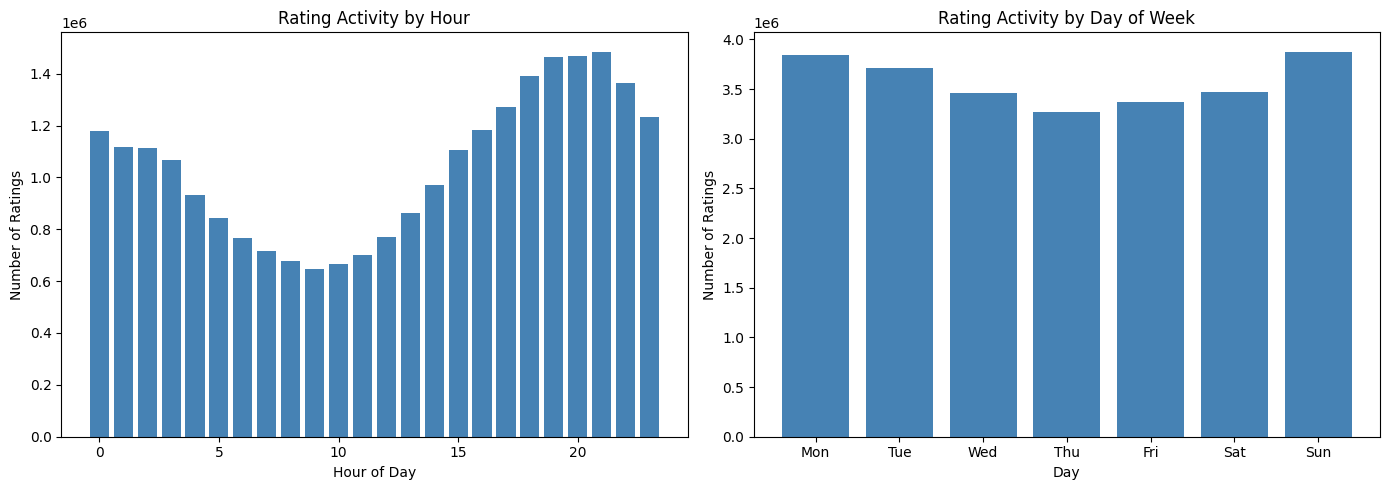

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hour distribution
axes[0].bar(ratings['hour'].value_counts().sort_index().index,
            ratings['hour'].value_counts().sort_index().values,
            color='steelblue')
axes[0].set_title('Rating Activity by Hour')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Number of Ratings')

# Day of week distribution
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1].bar(range(7),
            ratings['day_of_week'].value_counts().sort_index().values,
            color='steelblue')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(day_names)
axes[1].set_title('Rating Activity by Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Number of Ratings')

plt.tight_layout()
plt.show()